In [1]:
import mne
from src.preprocessing.loader import load_raw
from src.preprocessing.filter import apply_filters, make_epochs
from src.visualization.plot import plot_psd, plot_topomap
print(f"MNE version: {mne.__version__}")

MNE version: 1.12.1


In [2]:
sample_path = mne.datasets.sample.data_path()
raw_path = sample_path / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = load_raw(str(raw_path))
raw_eeg = raw.copy().pick_types(eeg=True, meg=False, stim=True, eog=False)

Opening raw data file C:\Users\ke725\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


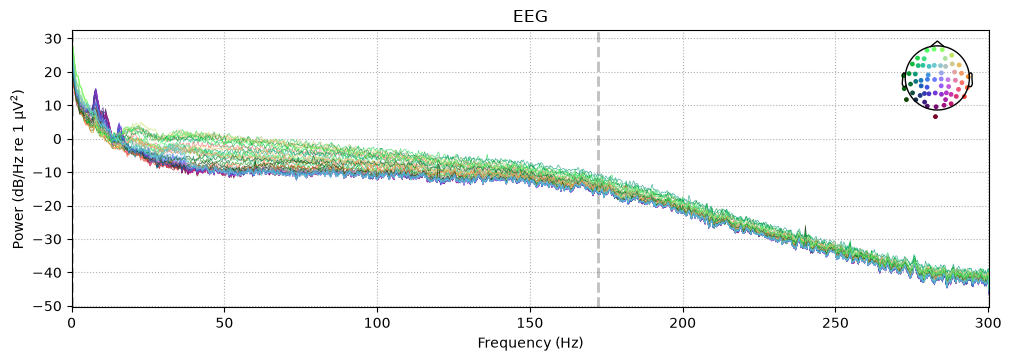

In [3]:
plot_psd(raw_eeg)

In [4]:
raw_filtered = raw_eeg.copy()
raw_filtered = apply_filters(raw_filtered, l_freq=1.0, h_freq=40.0, notch_freq=60.0)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 3965 samples (6.602 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge

Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


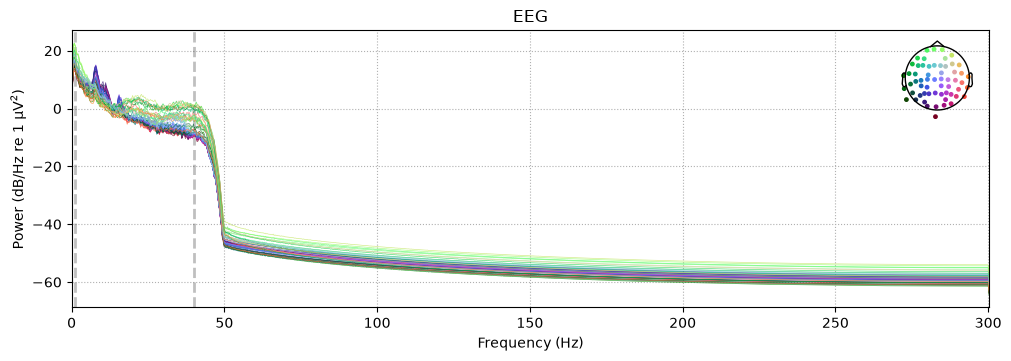

In [5]:
plot_psd(raw_filtered)

Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).
Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


C:\Users\ke725\AppData\Local\Temp\ipykernel_18940\1959670391.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


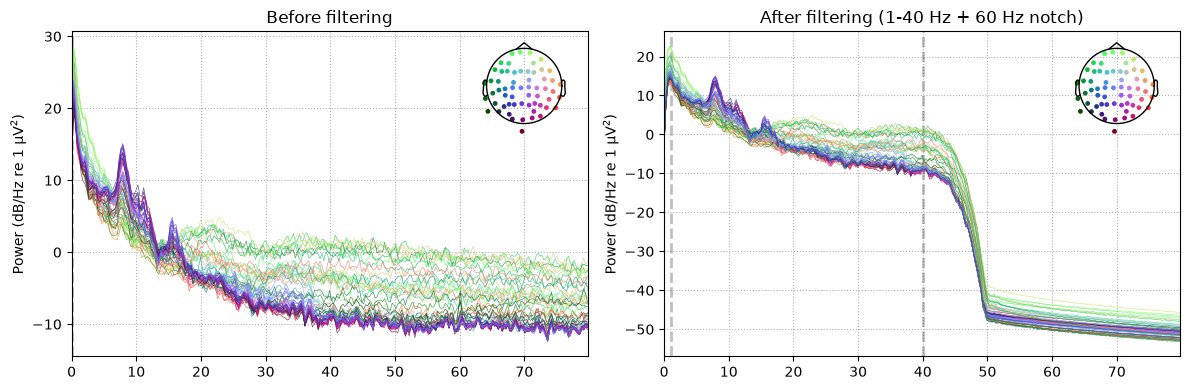

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw_eeg.compute_psd(fmax=80).plot(picks="eeg", axes=axes[0], show=False)
axes[0].set_title("Before filtering")
raw_filtered.compute_psd(fmax=80).plot(picks="eeg", axes=axes[1], show=False)
axes[1].set_title("After filtering (1-40 Hz + 60 Hz notch)")
plt.tight_layout()
plt.show()

In [7]:
epochs = make_epochs(raw_filtered, tmin=-0.2, tmax=0.8)
print(epochs)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
320 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 320 events and 601 original time points ...
0 bad epochs dropped
<Epochs | 320 events (all good), -0.2 – 0.799 s (baseline -0.2 – 0 s), ~102.7 MiB, data loaded,
 'auditory/left': 72
 'auditory/right': 73
 'visual/left': 73
 'visual/right': 71
 'smiley': 15
 'buttonpress': 16>


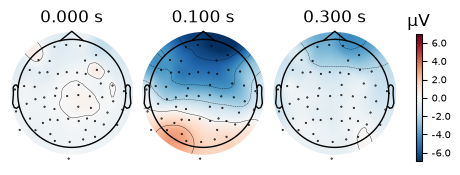

In [8]:
evoked = epochs.average()
plot_topomap(evoked, times=[0.0, 0.1, 0.3])